In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('playoff_challenge_2022-23.csv').set_index('team_id').iloc[:-1 , :]
df.head()

,Owner,QB,QB.1,RB,RB.1,WR,WR.1,WR.2,TE,FLX,FLX.1,K,D/ST
team_id,,,,,,,,,,,,,
1.0,Brad K1,Burrow,Allen,Ekeler,McCaffrey,Lamb,Jefferson,AJ Brown,Kelce,Barkley,Etienne,Myers,TB D/ST
2.0,Brad K2,Mahomes,Allen,Ekeler,Etienne,Evans,Jefferson,Chase,Kittle,Lamb,AJ Brown,Myers,NYG D/ST
3.0,Brad K3,Mahomes,Allen,Ekeler,Barkley,Evans,Jefferson,Chase,Schultz,McCaffrey,AJ Brown,Myers,JAX D/ST
4.0,Hack,Burrow,Hurts,Ekeler,McCaffrey,Jefferson,Diggs,Hill,Kelce,Barkley,Evans,Tucker,DAL D/ST
5.0,Christian 1,Mahomes,Allen,McCaffrey,Ekeler,Jefferson,Chase,Godwin,Schultz,Kirk,D Smith,Gano,SEA D/ST


In [3]:
all_qbs = pd.concat([df['QB'], df['QB.1']]).values
qb_counts = {qb:0 for qb in all_qbs}
for qb in all_qbs:
    qb_counts[qb] += 1
qb_counts = dict(sorted(qb_counts.items(), key=lambda item: item[1], reverse=True))

qb_combos_raw = [df['QB'].iloc[i] + '-' + df['QB.1'].iloc[i] for i in range(len(df))]
qb_combos = ['-'.join(sorted(C.split('-'))) for C in qb_combos_raw]
combos = {qb:0 for qb in qb_combos}
for qb in qb_combos:
    combos[qb] += 1
combos = dict(sorted(combos.items(), key=lambda item: item[1], reverse=True))

/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/1633090933.py:19: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(list(qb_counts.keys()), rotation = 45, fontsize=14, fontweight='bold')
/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/1633090933.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(list(combos.keys()), rotation = 70, fontsize=14)


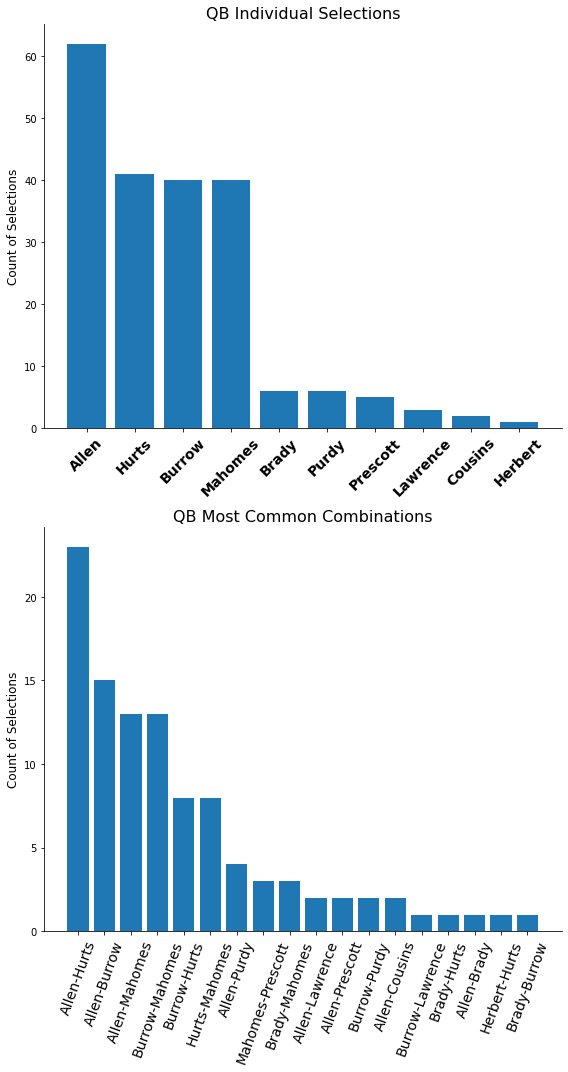

In [12]:
all_qbs = pd.concat([df['QB'], df['QB.1']]).values
qb_counts = {qb:0 for qb in all_qbs}
for qb in all_qbs:
    qb_counts[qb] += 1
qb_counts = dict(sorted(qb_counts.items(), key=lambda item: item[1], reverse=True))

qb_combos_raw = [df['QB'].iloc[i] + '-' + df['QB.1'].iloc[i] for i in range(len(df))]
qb_combos = ['-'.join(sorted(C.split('-'))) for C in qb_combos_raw]
combos = {qb:0 for qb in qb_combos}
for qb in qb_combos:
    combos[qb] += 1
combos = dict(sorted(combos.items(), key=lambda item: item[1], reverse=True))

fig, ax = plt.subplots(2, 1, figsize=(8,15))

ax[0].bar(list(qb_counts.keys()), list(qb_counts.values()))
ax[0].set_title('QB Individual Selections', fontsize=16)
ax[0].set_ylabel('Count of Selections', fontsize=12)
ax[0].set_xticklabels(list(qb_counts.keys()), rotation = 45, fontsize=14, fontweight='bold')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].bar(list(combos.keys()), list(combos.values()))
ax[1].set_title('QB Most Common Combinations', fontsize=16)
ax[1].set_ylabel('Count of Selections', fontsize=12)
ax[1].set_xticklabels(list(combos.keys()), rotation = 70, fontsize=14)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
all_rbs = list(pd.concat([df['RB'], df['RB.1']]).values)
all_wrs = list(pd.concat([df['WR'], df['WR.1'], df['WR.2']]).values)
tes = list(pd.concat([df['TE']]).values)
all_flex = list(pd.concat([df['FLX'], df['FLX.1']]).values)

for flx in all_flex:
    if flx in all_rbs or flx == 'J Cook':
        all_rbs.append(flx)
    elif flx in all_wrs or flx == 'Davis':
        all_wrs.append(flx)
    else:
        tes.append(flx)

/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/541758440.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(list(rb_counts.keys()), rotation = 45, fontsize=14, fontweight='bold')
/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/541758440.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(list(combos.keys()), rotation = 70, fontsize=14)


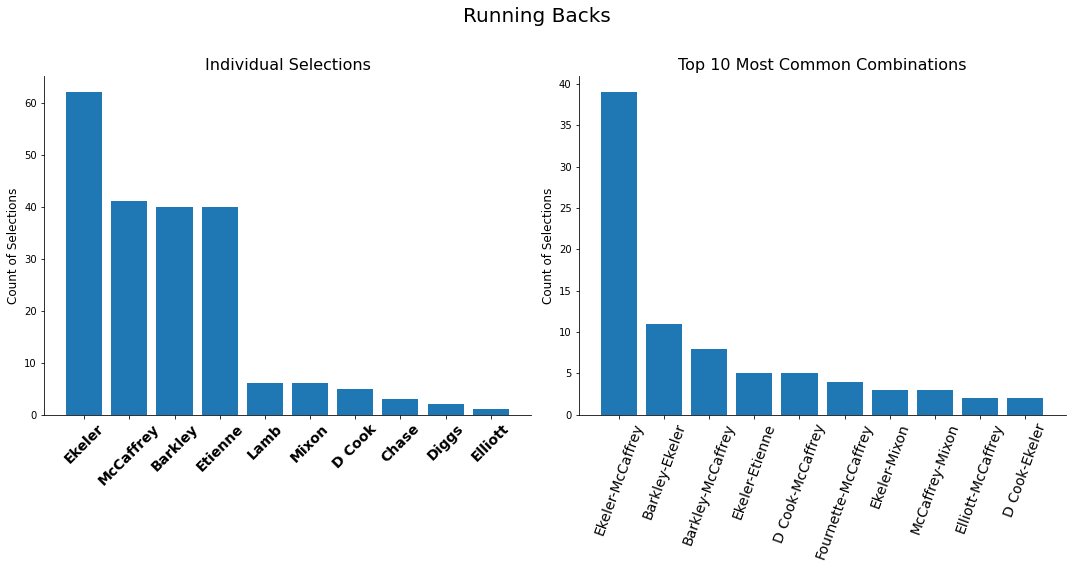

In [15]:
rb_counts = {rb:0 for rb in all_rbs}
for rb in all_rbs:
    rb_counts[rb] += 1
rb_counts = dict(sorted(rb_counts.items(), key=lambda item: item[1], reverse=True))

rb_combos_raw = [df['RB'].iloc[i] + '-' + df['RB.1'].iloc[i] for i in range(len(df))]
rb_combos = ['-'.join(sorted(C.split('-'))) for C in rb_combos_raw]
combos = {rb:0 for rb in rb_combos}
for rb in rb_combos:
    combos[rb] += 1
combos = dict(sorted(combos.items(), key=lambda item: item[1], reverse=True)[:10])

fig, ax = plt.subplots(1, 2, figsize=(15,8))

ax[0].bar(list(qb_counts.keys()), list(qb_counts.values()))
ax[0].set_title('Individual Selections', fontsize=16)
ax[0].set_ylabel('Count of Selections', fontsize=12)
ax[0].set_xticklabels(list(rb_counts.keys()), rotation = 45, fontsize=14, fontweight='bold')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].bar(list(combos.keys()), list(combos.values()))
ax[1].set_title('Top 10 Most Common Combinations', fontsize=16)
ax[1].set_ylabel('Count of Selections', fontsize=12)
ax[1].set_xticklabels(list(combos.keys()), rotation = 70, fontsize=14)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.suptitle('Running Backs\n', fontsize=20)
plt.tight_layout()
plt.show()

/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/3385629191.py:18: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(list(wr_counts.keys()), rotation = 45, fontsize=14, fontweight='bold')
/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/3385629191.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(list(combos.keys()), rotation = 70, fontsize=14)


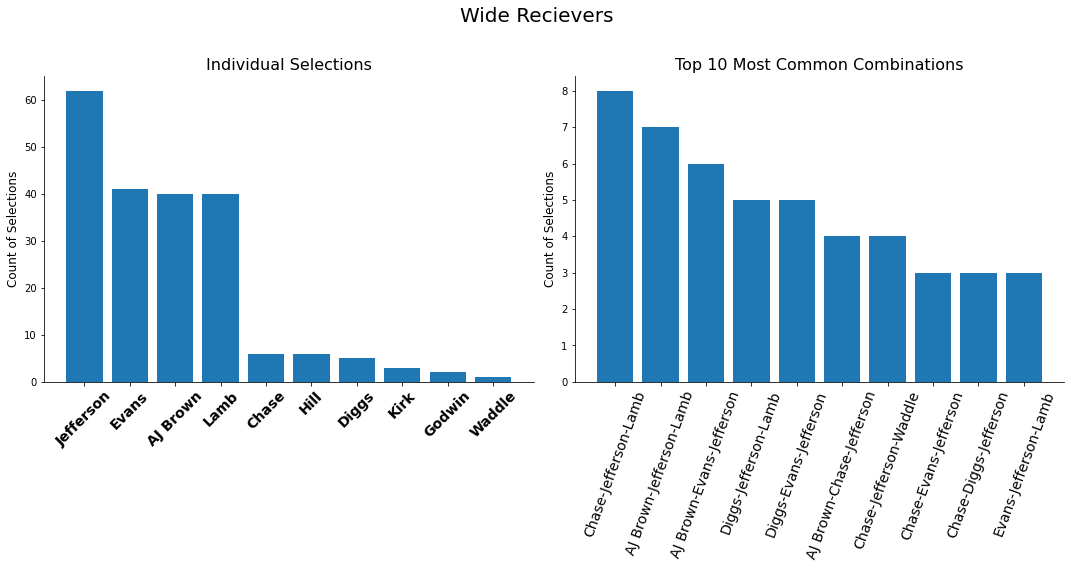

In [16]:
wr_counts = {wr:0 for wr in all_wrs}
for wr in all_wrs:
    wr_counts[wr] += 1
wr_counts = dict(sorted(wr_counts.items(), key=lambda item: item[1], reverse=True))

wr_combos_raw = [df['WR'].iloc[i] + '-' + df['WR.1'].iloc[i] + '-' + df['WR.2'].iloc[i] for i in range(len(df))]
wr_combos = ['-'.join(sorted(C.split('-'))) for C in wr_combos_raw]
combos = {wr:0 for wr in wr_combos}
for wr in wr_combos:
    combos[wr] += 1
combos = dict(sorted(combos.items(), key=lambda item: item[1], reverse=True)[:10])

fig, ax = plt.subplots(1, 2, figsize=(15,8))

ax[0].bar(list(qb_counts.keys()), list(qb_counts.values()))
ax[0].set_title('Individual Selections', fontsize=16)
ax[0].set_ylabel('Count of Selections', fontsize=12)
ax[0].set_xticklabels(list(wr_counts.keys()), rotation = 45, fontsize=14, fontweight='bold')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].bar(list(combos.keys()), list(combos.values()))
ax[1].set_title('Top 10 Most Common Combinations', fontsize=16)
ax[1].set_ylabel('Count of Selections', fontsize=12)
ax[1].set_xticklabels(list(combos.keys()), rotation = 70, fontsize=14)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

plt.suptitle('Wide Recievers\n', fontsize=20)
plt.tight_layout()
plt.show()

/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/1872294987.py:24: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[0].set_xticklabels(list(te_counts.keys()), rotation = 45, fontsize=14)
/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/1872294987.py:31: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(list(k_counts.keys()), rotation = 45, fontsize=14)
/var/folders/mf/tvg4nmds1zs6fkm_hx2t_dhh0000gn/T/ipykernel_1170/1872294987.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[2].set_xticklabels(list(dst_counts.keys()), rotation = 45, fontsize=14)


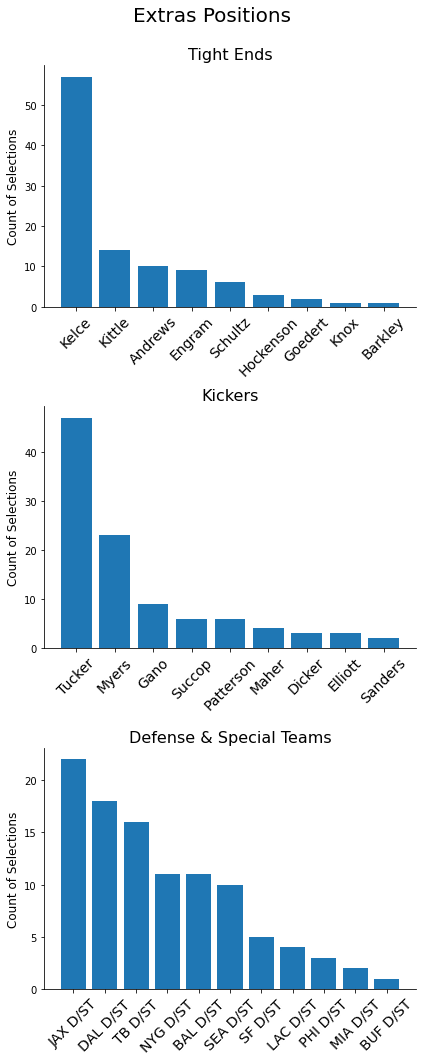

In [10]:
te_counts = {te:0 for te in tes}
for te in tes:
    te_counts[te] += 1
te_counts = dict(sorted(te_counts.items(), key=lambda item: item[1], reverse=True))

ks = pd.concat([df['K']]).values
k_counts = {k:0 for k in ks}
for k in ks:
    k_counts[k] += 1
k_counts = dict(sorted(k_counts.items(), key=lambda item: item[1], reverse=True))

dst = pd.concat([df['D/ST']]).values
dst_counts = {d:0 for d in dst}
for d in dst:
    dst_counts[d] += 1
dst_counts = dict(sorted(dst_counts.items(), key=lambda item: item[1], reverse=True))

fig, ax = plt.subplots(3,1, figsize=(6,15))

ax[0].bar(list(te_counts.keys()), list(te_counts.values()))
ax[0].set_title('Tight Ends', fontsize=16)
ax[0].set_ylabel('Count of Selections', fontsize=12)
ax[0].set_xticklabels(list(te_counts.keys()), rotation = 45, fontsize=14)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

ax[1].bar(list(k_counts.keys()), list(k_counts.values()))
ax[1].set_title('Kickers', fontsize=16)
ax[1].set_ylabel('Count of Selections', fontsize=12)
ax[1].set_xticklabels(list(k_counts.keys()), rotation = 45, fontsize=14)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[2].bar(list(dst_counts.keys()), list(dst_counts.values()))
ax[2].set_title('Defense & Special Teams', fontsize=16)
ax[2].set_ylabel('Count of Selections', fontsize=12)
ax[2].set_xticklabels(list(dst_counts.keys()), rotation = 45, fontsize=14)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)

plt.suptitle('Extras Positions\n', fontsize=20)
plt.tight_layout()
plt.show()

In [8]:
list(dst_counts.keys()), list(dst_counts.values())

(['JAX D/ST',
  'DAL D/ST',
  'TB D/ST',
  'NYG D/ST',
  'BAL D/ST',
  'SEA D/ST',
  'SF D/ST',
  'LAC D/ST',
  'PHI D/ST',
  'MIA D/ST',
  'BUF D/ST'],
 [22, 18, 16, 11, 11, 10, 5, 4, 3, 2, 1])